In [29]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

from IPython.display import display

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [30]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
try:
    fields = np.load('data/fields.npy')
except:
    np.random.seed(1234)
    fields = []
    for a in alphas:
        fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
    np.save('data/fields.npy', fields)

In [165]:
IDX = 13
lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in fields[IDX].shape])
corr2 = corr.process_lags(fields[IDX], fields[IDX], lv2, periodic=False, lenn=phys_dims, shape=tuple([2*n+1 for n in fields[IDX].shape]))
lvm = statfunc_base.get_lagvec_magnitude_array(corr2.shape)# * L/N
l_true, corr_true, _ = statistics_base.bin_data(lvm, corr2, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
l_true = l_true  * L/N

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [195]:
IDX = 13
lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in fields[IDX].shape])
sf2 = strfn.process_lags(fields[IDX], fields[IDX], lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in fields[IDX].shape]), orders=[2])[0]
lvm = statfunc_base.get_lagvec_magnitude_array(sf2.shape)# * L/N
lsf_true, sf_true, _ = statistics_base.bin_data(lvm, sf2, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
lsf_true = lsf_true  * L/N

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [196]:
import sympy as sp
x = sp.symbols('x', positive=True, real=True)
E = sp.symbols('E', positive=True, integer=True)

lim = sp.limit(sp.besselj(E/2 - 1, x) / x**(E/2 - 1), x, 0)

display(lim)


     E
 1 - ─
     2
2     
──────
  ⎛E⎞ 
 Γ⎜─⎟ 
  ⎝2⎠ 

In [197]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k, l = sp.symbols('k l', positive=True, real=True)
a = sp.symbols('a', positive=True, real=True)
Kl, Kh = sp.symbols('Kl Kh', positive=True, real=True)

a = -alphas[IDX]
print('POWERLAW', a)
Kl = np.nanmin(2*np.pi/l_true)
Kh = np.nanmax(2*np.pi/l_true)

E = sp.Piecewise(
    (1, k < Kl),
    (0, k >= Kh),
    (k**(-a), True)
    #((k**(-a) - Kh**(-a)) / (Kl**(-a) - Kh**(-a)), True),
)

S_E = 2.*np.pi
norm = (2.*sp.pi)**2

s2 = sp.integrate(S_E * k * E, (k, 0, sp.oo))

acf = sp.integrate(S_E * k * E * sp.besselj(0, k*l), (k, 0, sp.oo))

sf = 2*s2 - 2*acf

eps = 1. / (4. * sp.pi) * l**2 * sp.Abs(sp.diff(sf, l))

display(E)
display(s2)
display(acf)
display(sf)
display(eps)


POWERLAW 3.7368421052631575


⎧        1           for k < 1.0034513237914 
⎪                                            
⎪        0           for k ≥ 170.974420623789
⎨                                            
⎪ -3.73684210526316                          
⎪k                          otherwise        
⎩                                            

6.75884477559224

                        ┌─  ⎛  -0.868421052631579   │                    2⎞   
- 0.000478818262156013⋅ ├─  ⎜                       │ -7308.06312691012⋅l ⎟ + 
                       1╵ 2 ⎝0.131578947368421, 1.0 │                     ⎠   

                  ┌─  ⎛  -0.868421052631579   │                     2⎞   6.304
3.59600821182029⋅ ├─  ⎜                       │ -0.251728639804678⋅l ⎟ + ─────
                 1╵ 2 ⎝0.131578947368421, 1.0 │                      ⎠        

87061411603⋅besselj(1, 1.0034513237914⋅l)
─────────────────────────────────────────
                 l                       

                      ┌─  ⎛  -0.868421052631579   │                    2⎞     
0.000957636524312025⋅ ├─  ⎜                       │ -7308.06312691012⋅l ⎟ - 7.
                     1╵ 2 ⎝0.131578947368421, 1.0 │                     ⎠     

                ┌─  ⎛  -0.868421052631579   │                     2⎞          
19201642364057⋅ ├─  ⎜                       │ -0.251728639804678⋅l ⎟ + 13.5176
               1╵ 2 ⎝0.131578947368421, 1.0 │                      ⎠          

            12.6097412282321⋅besselj(1, 1.0034513237914⋅l)
895511845 - ──────────────────────────────────────────────
                                  l                       

      2 │                    ┌─  ⎛  0.131578947368421   │                    2
0.25⋅l ⋅│92.3797798744533⋅l⋅ ├─  ⎜                      │ -7308.06312691012⋅l 
        │                   1╵ 2 ⎝1.13157894736842, 2.0 │                     
        │                                                                     
──────────────────────────────────────────────────────────────────────────────
                                                                              

⎞                       ┌─  ⎛  0.131578947368421   │                     2⎞   
⎟ - 23.8977619554425⋅l⋅ ├─  ⎜                      │ -0.251728639804678⋅l ⎟ - 
⎠                      1╵ 2 ⎝1.13157894736842, 2.0 │                      ⎠   
                                                                              
──────────────────────────────────────────────────────────────────────────────
                                                                              

12.6097412282321⋅(0.5017256618957⋅besselj(0, 1.003

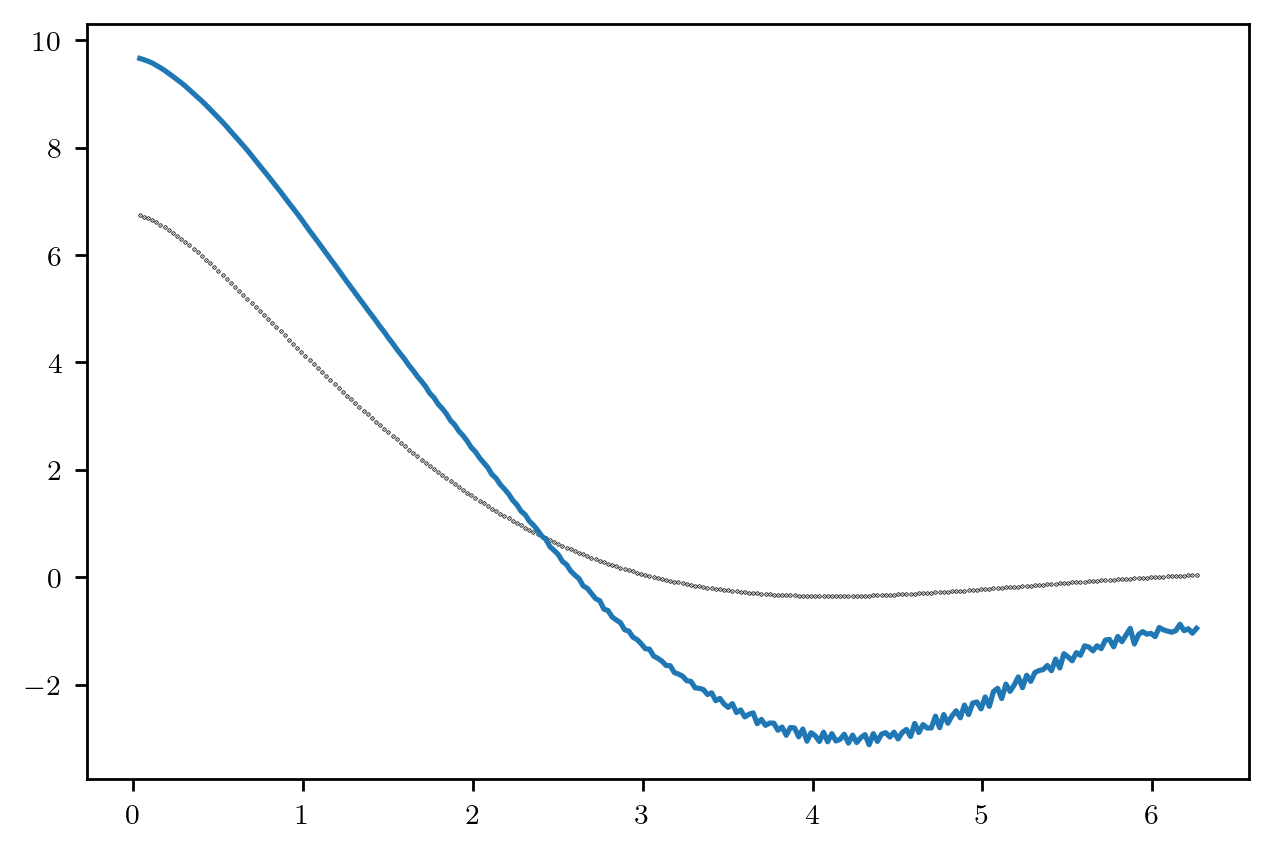

In [198]:
import mpmath as mp
lam_acf = sp.lambdify(l, acf, modules=['scipy', 'numpy', 'mpmath'])
for _ell in l_true:
    plt.scatter(_ell, lam_acf(_ell), marker='.', color='black', s=0.2)
plt.plot(l_true, corr_true)

[]

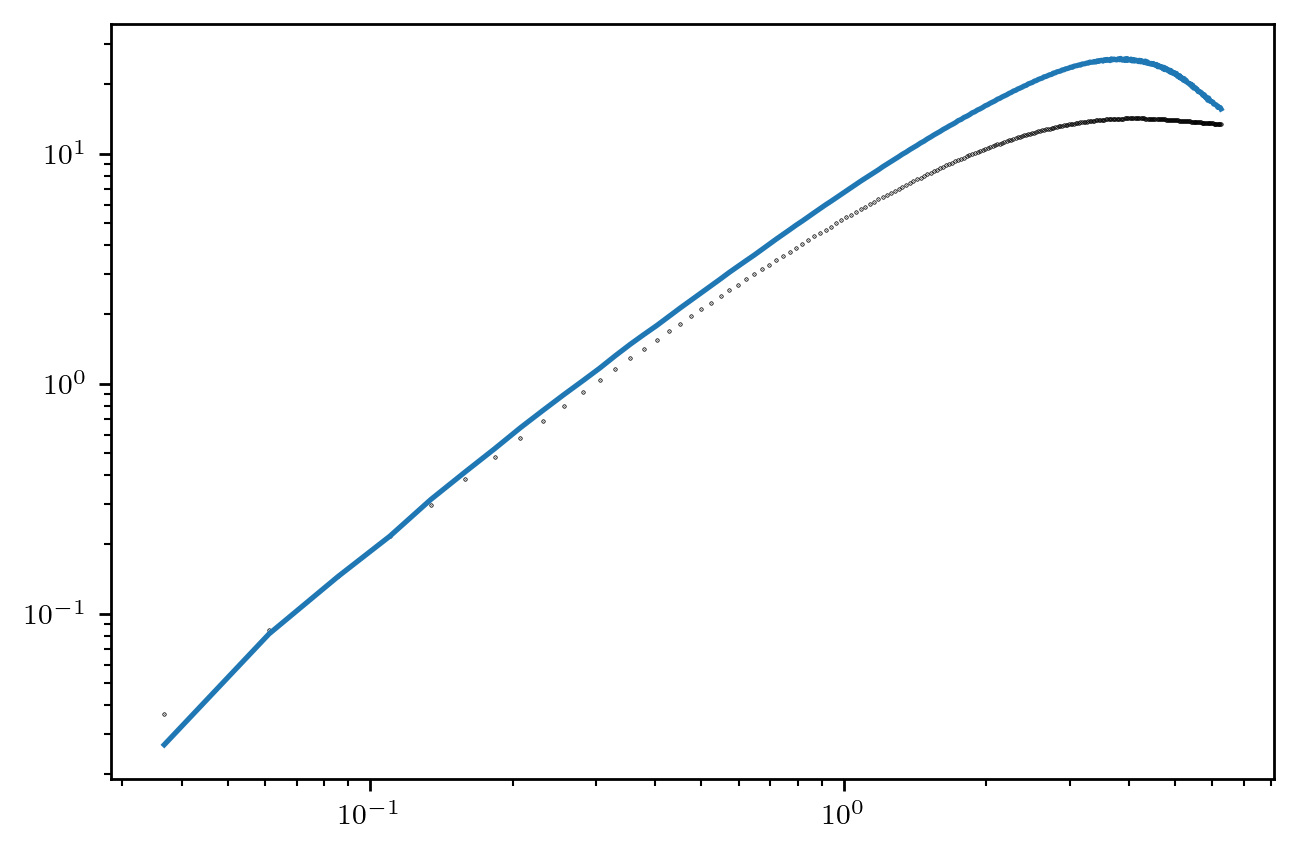

In [199]:
lam_sf = sp.lambdify(l, sf, modules=['scipy', 'numpy', 'mpmath'])
for _ell in l_true:
    plt.scatter(_ell, lam_sf(_ell), marker='.', color='black', s=0.2)
#plt.xlim(1., 2.*np.pi)
plt.plot(lsf_true, sf_true)
plt.loglog()

-2.353779788160863
-2.7368421052631575


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[]

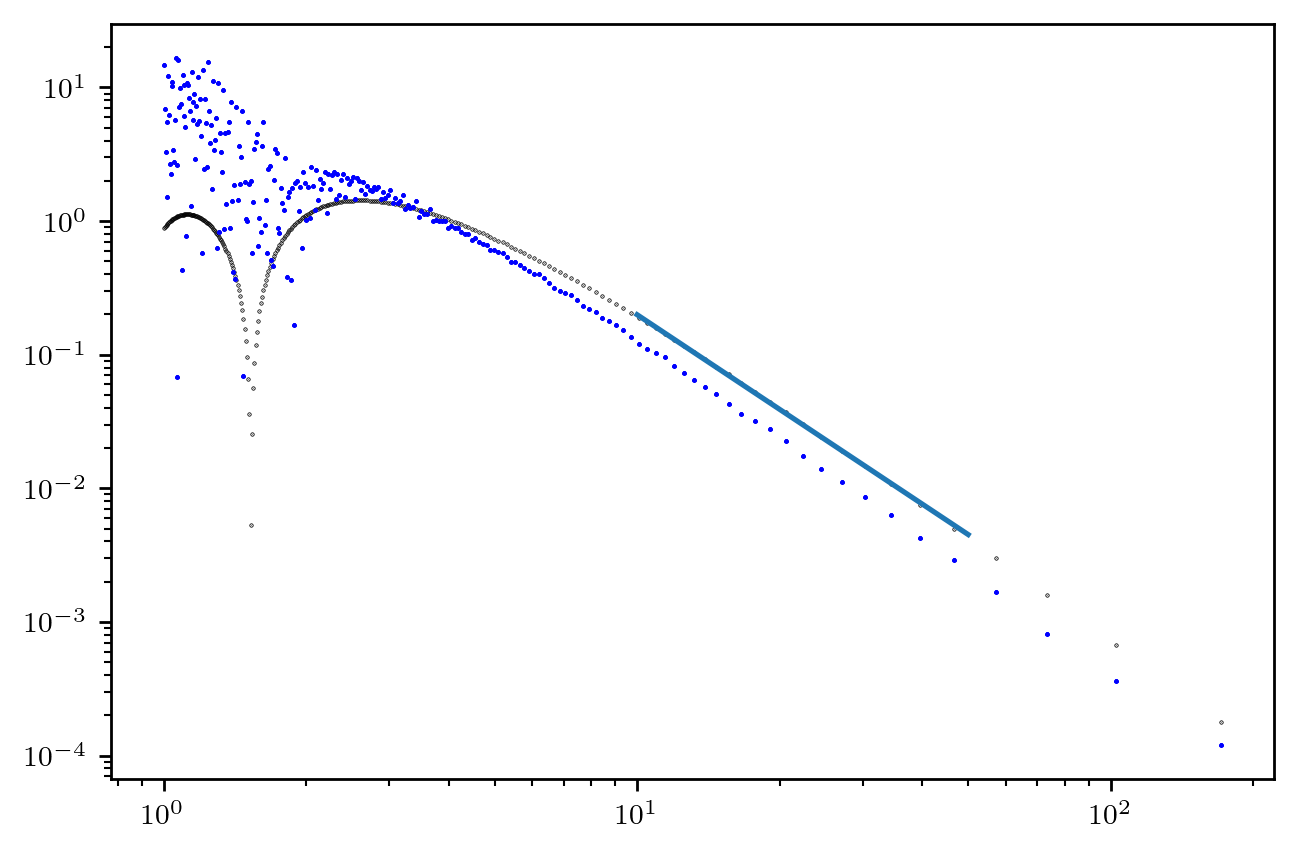

In [200]:
lam_eps = sp.lambdify(l, eps, modules=['scipy', 'numpy', 'mpmath'])
_ellz = []
_epsz = []
for _ell in l_true:
    _ellz.append(2.*np.pi/_ell)
    _epsz.append(lam_eps(_ell))

_ellz = np.array(_ellz, dtype='float')[::-1]
_epsz = np.array(_epsz, dtype='float')[::-1]

plt.scatter(_ellz, _epsz, marker='.', color='black', s=0.2)
plt.loglog()

z, xx, p = fit_base.fit_powerlaw(_ellz, _epsz, 10, 50)
plt.plot(xx, p)
print(z[0])
print(-a + 1)

l_eps, sf_eps = strfn_spectra.omni_spectrum_2(sf2, lenn=L)
plt.scatter(l_eps, np.abs(sf_eps), marker='*', color='blue', s=0.2)

plt.loglog()

In [201]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

def get_semianalytical_eps_alpha(a):
    k, l = sp.symbols('k l', positive=True, real=True)
    #a = sp.symbols('a', positive=True, real=True)
    Kl, Kh = sp.symbols('Kl Kh', positive=True, real=True)

    #a = -alphas[IDX]
    Kl = np.nanmin(2*np.pi/l_true)
    Kh = np.nanmax(2*np.pi/l_true)

    E = sp.Piecewise(
        (1, k < Kl),
        (0, k >= Kh),
        (k**(-a), True)
        #((k**(-a) - Kh**(-a)) / (Kl**(-a) - Kh**(-a)), True),
    )

    s2 = sp.symbols('s2')
    s2 = sp.integrate(2 * sp.pi * k * E, (k, 0, sp.oo))
    s2 = 1.

    J0 = sp.besselj(0, k*l)
    acf = sp.integrate(2 * sp.pi * E * J0 * k, (k, 0, sp.oo))
    sf = 2*s2*(1 - acf)
    eps = (2*sp.pi)**2 / (8 * sp.pi) * l**2 * sp.diff(sf, l)

    lam_eps = sp.lambdify(l, eps, modules=['scipy', 'numpy', 'mpmath'])

    _ellz = []
    _epsz = []
    for _ell in l_true:
        _ellz.append(2.*np.pi/_ell)
        _epsz.append(lam_eps(_ell))

    _ellz = np.array(_ellz, dtype='float')[::-1]
    _epsz = np.array(_epsz, dtype='float')[::-1]

    z, xx, p = fit_base.fit_powerlaw(_ellz, _epsz, 10., 50.)
    return z[0]

def get_semianalytical_eps(a, i_k):
    k, l = sp.symbols('k l', positive=True, real=True)
    #a = sp.symbols('a', positive=True, real=True)
    Kl, Kh = sp.symbols('Kl Kh', positive=True, real=True)

    #a = -alphas[IDX]
    Kl = np.nanmin(2*np.pi/l_true)
    Kh = np.nanmax(2*np.pi/l_true)

    E = sp.Piecewise(
        (1, k < Kl),
        (0, k >= Kh),
        (k**(-a), True)
        #((k**(-a) - Kh**(-a)) / (Kl**(-a) - Kh**(-a)), True),
    )

    s2 = sp.symbols('s2')
    s2 = sp.integrate(2 * sp.pi * k * E, (k, 0, sp.oo))
    s2 = 1.

    J0 = sp.besselj(0, k*l)
    acf = sp.integrate(2 * sp.pi * E * J0 * k, (k, 0, sp.oo))
    sf = 2*s2*(1 - acf)
    eps = (2*sp.pi)**2 / (8 * sp.pi) * l**2 * sp.diff(sf, l)

    lam_eps = sp.lambdify(l, eps, modules=['scipy', 'numpy', 'mpmath'])

    _ellz = []
    _epsz = []
    for _ell in l_true:
        _ellz.append(2.*np.pi/_ell)
        _epsz.append(lam_eps(_ell))

    _ellz = np.array(_ellz, dtype='float')[::-1]
    _epsz = np.array(_epsz, dtype='float')[::-1]

    i_epsz = strfn_spectra.interpolate(_ellz, _epsz, i_k)
    return i_epsz


In [202]:
try:
    models = np.load('data/models.npy')
except:
    models = []
    for i, a in enumerate(alphas):
        k, _, _ = spectra_base.calculate_integrated_spectrum((fields[i],), spec_type='modal', lenn=phys_dims)
        models.append(fbm.funcs.smooth_pow(k, (a,), (1.,)))
try:
    komni = np.load('data/komni.npy')
except:    
    komni = []
    for f in fields:
        k, fek, _ = spectra_base.calculate_integrated_spectrum((f,), spec_type='omni', lenn=phys_dims, int_kwargs={'norm_bin_size': True})
        komni.append((k, fek))
    np.save('data/komni.npy', komni)
try:
    sfs = np.load('data/sfs.npy')
except:
    sfs = []
    for f in fields:
        lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in f.shape])
        sf2 = strfn.process_lags(f, f, lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in f.shape]), orders=[2])[0]
        sfs.append(sf2)

In [203]:
STRFN_MIN, STRFN_MAX = 10., 50.
sf2_pwrl = {}
a_pwrl = {}

sf2_bias = {}
a_bias = {}

for i, ll in enumerate(sfs):
    k, fek = strfn_spectra.omni_spectrum_2(ll)
    i_sf_fek = strfn_spectra.interpolate(k, fek, komni[i][0])
    z, xx, p = fit_base.fit_powerlaw(k, fek, STRFN_MIN, STRFN_MAX)

    sf2_pwrl[-alphas[i]] = (z[0], alphas[i] + 1.)
    _a = get_semianalytical_eps_alpha(-alphas[i])
    a_pwrl[-alphas[i]] = (_a, alphas[i] + 1.)

    sf2_bias[-alphas[i]] = i_sf_fek / komni[i][1]
    a_bias[-alphas[i]] = get_semianalytical_eps(-alphas[i], komni[i][0]) / komni[i][1]

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')
/home/m/Documents/science_codes/Kea/Kea/fitting/fit_base.py:31: RuntimeWarning: invalid value encountered in log
  z = np.polyfit(np.log(ax[idxi:idxf]), np.log(ay[idxi:idxf]), 1)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarnin

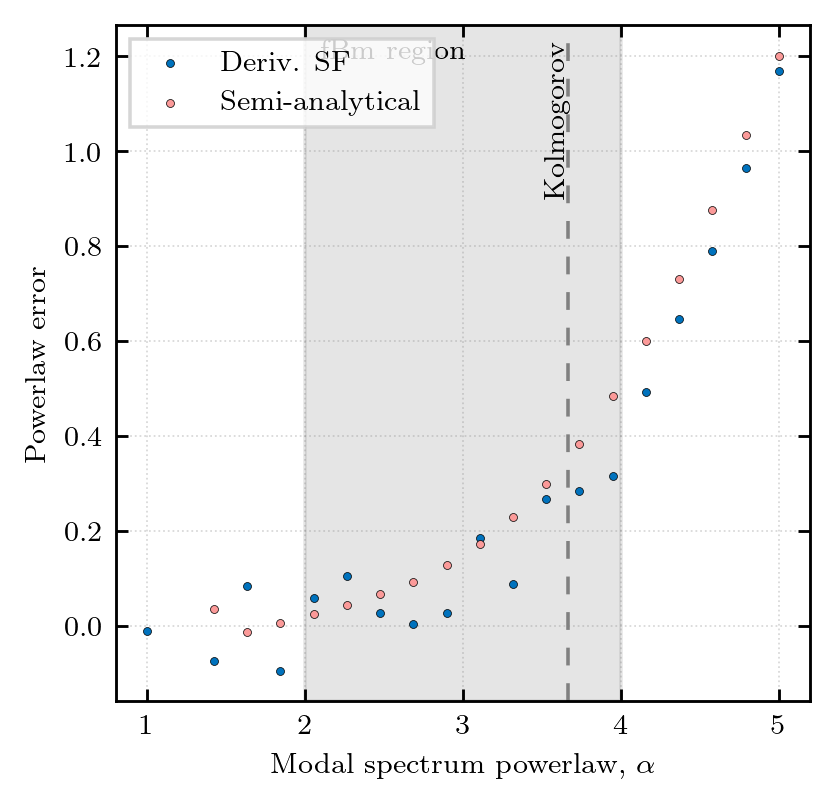

In [204]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in sf2_pwrl.keys():
    ax.scatter(a, (sf2_pwrl[a][0] - sf2_pwrl[a][1]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

for a in a_pwrl.keys():
    ax.scatter(a, (a_pwrl[a][0] - a_pwrl[a][1]), marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

ax.scatter([], [], marker='o', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Deriv. SF')
ax.scatter([], [], marker='o', s=5., color=c[3], linewidth=0.2, edgecolor='black', label=r'Semi-analytical')
ax.legend(fancybox=False, frameon=True)

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=1., zorder=0)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(2.1, 0.95, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Powerlaw error')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

fig.savefig('plots/fbm_pwrlaw_bias_analytical.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/fbm_pwrlaw_bias_analytical.png', transparent=True, bbox_inches='tight', pad_inches=0)


[]

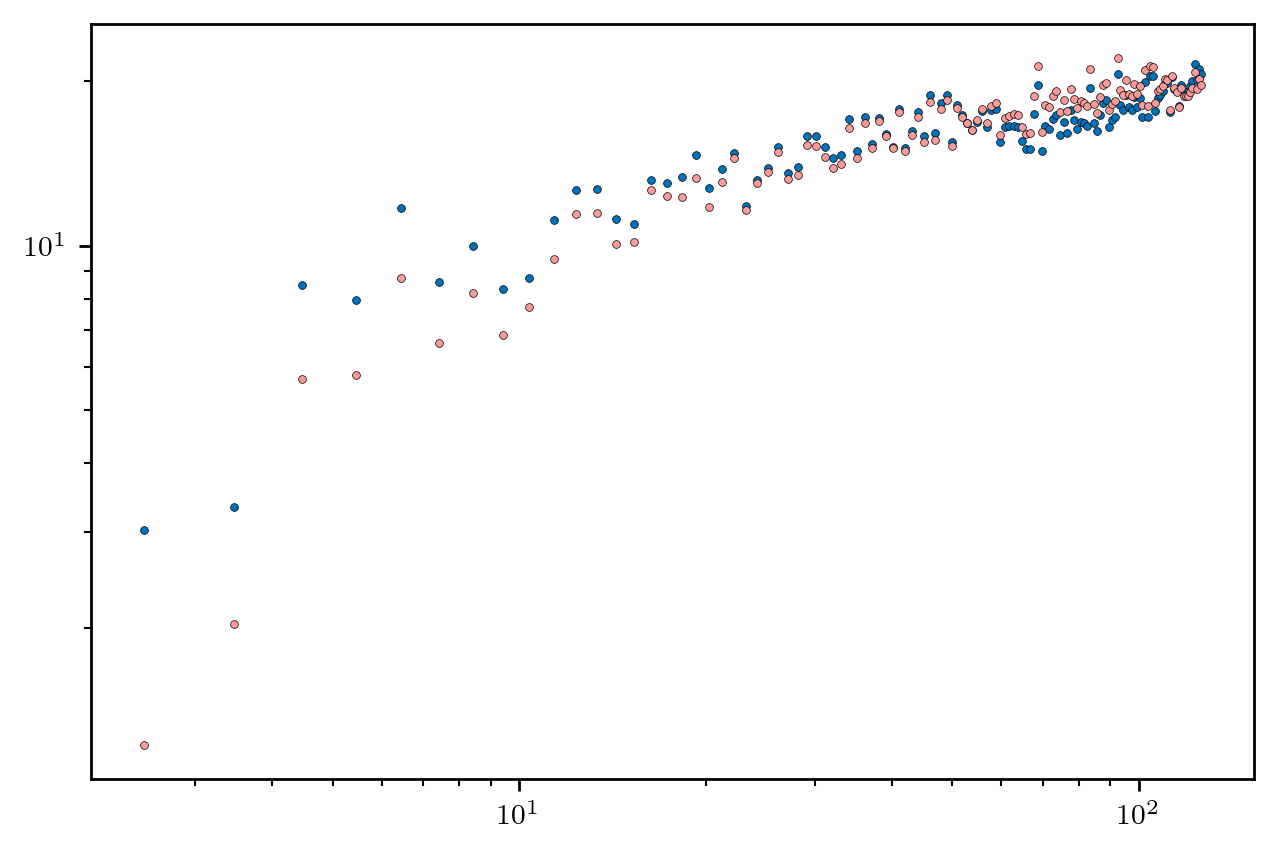

In [205]:
plt.scatter(komni[13][0], sf2_bias[-alphas[13]], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
plt.scatter(komni[13][0], a_bias[-alphas[13]]/35., marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')
plt.loglog()

/tmp/ipykernel_8139/3265922006.py:13: RuntimeWarning: Mean of empty slice
  ax.scatter(a, np.nanmean(a_bias[a][idx_min:idx_max]/35.), marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')


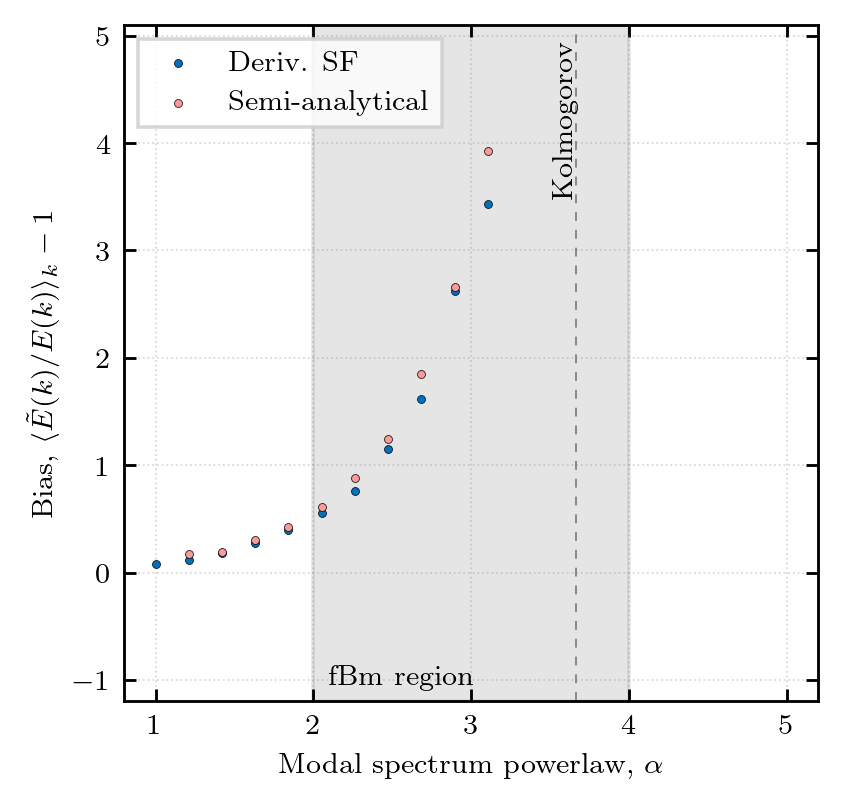

In [206]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i, a in enumerate(sf2_bias.keys()):
    idx_min = (np.abs(komni[i][0] - STRFN_MIN)).argmin()
    idx_max = (np.abs(komni[i][0] - STRFN_MAX)).argmin()
    ax.scatter(a, np.nanmean(sf2_bias[a][idx_min:idx_max]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

for i, a in enumerate(a_bias.keys()):
    idx_min = (np.abs(komni[i][0] - STRFN_MIN)).argmin()
    idx_max = (np.abs(komni[i][0] - STRFN_MAX)).argmin()
    ax.scatter(a, np.nanmean(a_bias[a][idx_min:idx_max]/35.), marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

ax.scatter([], [], marker='o', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Deriv. SF')
ax.scatter([], [], marker='o', s=5., color=c[3], linewidth=0.2, edgecolor='black', label=r'Semi-analytical')
# ax.scatter([], [], marker='P', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Periodogram')
# ax.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Ar\'evalo')
#ax.plot([], [], color='black', linewidth=0.5, linestyle=(0,(5,5)), label=r'Analytical Ar\'evalo')
ax.legend(fancybox=False, frameon=True, loc='upper left')

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=0.5, zorder=0)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(2.1, 0.025, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Bias, $\langle \\tilde{E}(k)/E(k) \\rangle_{k} - 1$')
ax.set_xlabel('Modal spectrum powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.set_ylim((-1.2, 5.1))

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#fig.subplots_adjust(wspace=0.05)
fig.savefig('plots/fbm_spectra_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/fbm_spectra_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)
